In [16]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#load dataset
df = pd.read_csv('sample_superstore.csv', encoding='latin1')
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200


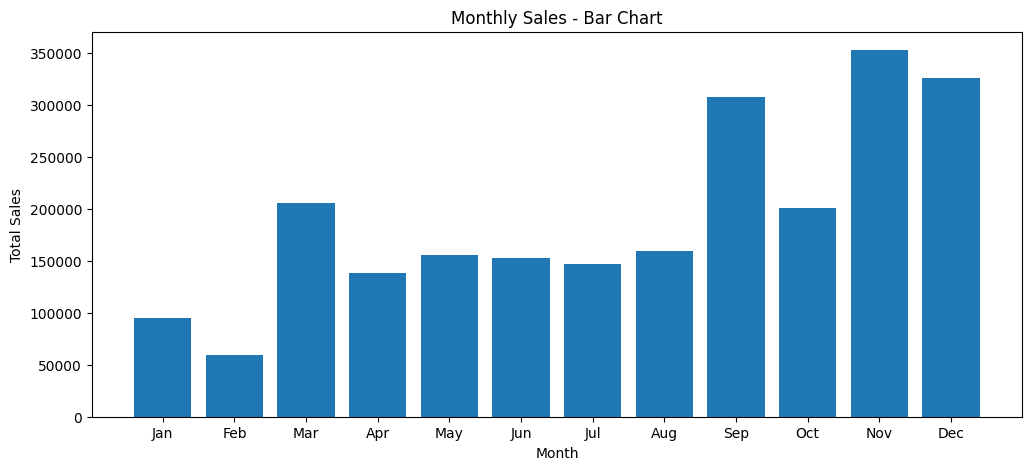

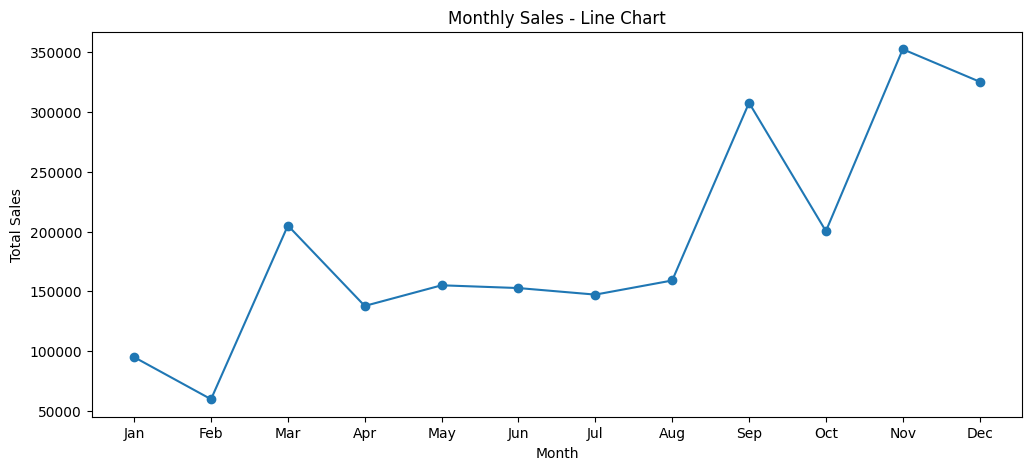

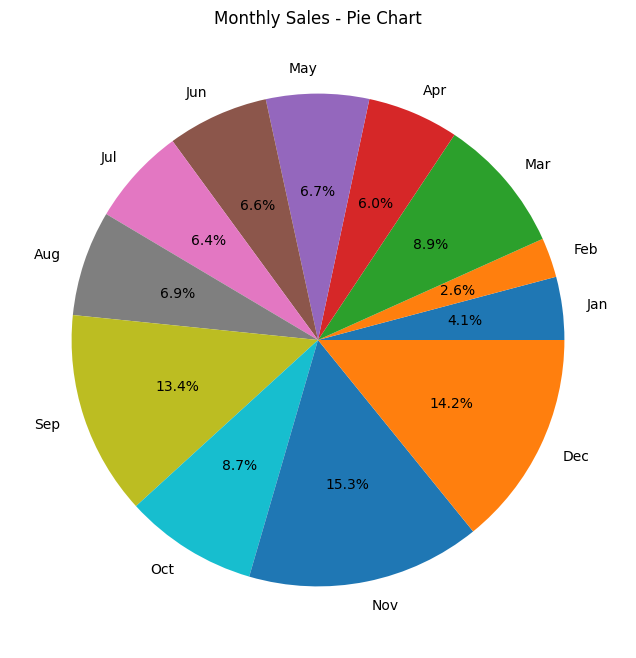

The best graph to represent the monthly sales is the line graph as we are showing a trend of sales over time


In [38]:
#Task 1:
df['Order Date'] = pd.to_datetime(df['Order Date'])

monthly_sales = df.groupby(df['Order Date'].dt.month)['Sales'].sum()

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

monthly_sales = monthly_sales.reindex(range(1, 13), fill_value=0)

plt.figure(figsize=(12, 5))
plt.bar(months, monthly_sales.values)
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.title('Monthly Sales - Bar Chart')
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(months, monthly_sales.values, marker='o')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.title('Monthly Sales - Line Chart')
plt.show()

plt.figure(figsize=(8, 8))
plt.pie(monthly_sales.values, labels=months, autopct='%1.1f%%')
plt.title('Monthly Sales - Pie Chart')
plt.show()

print("The best graph to represent the monthly sales is the line graph as we are showing a trend of sales over time")

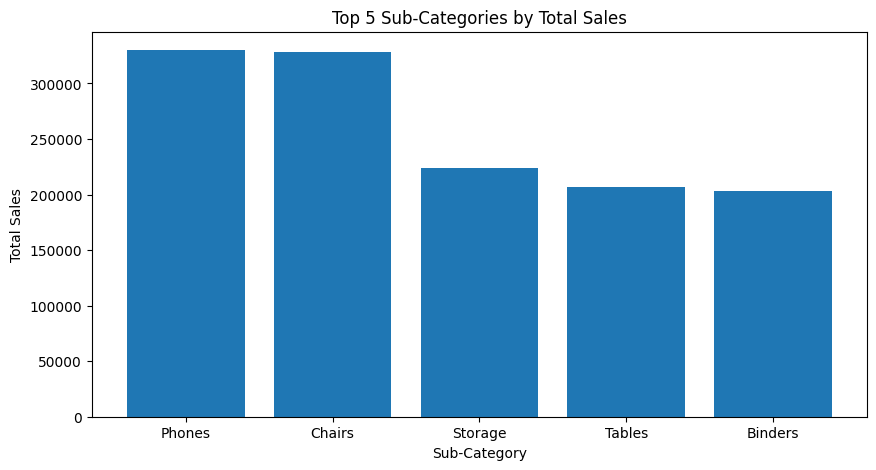

Bar chart is the best option to compare the magnitude across catogeries
The pie chart would be a weak option as it would exceed the 4 catogeries limit


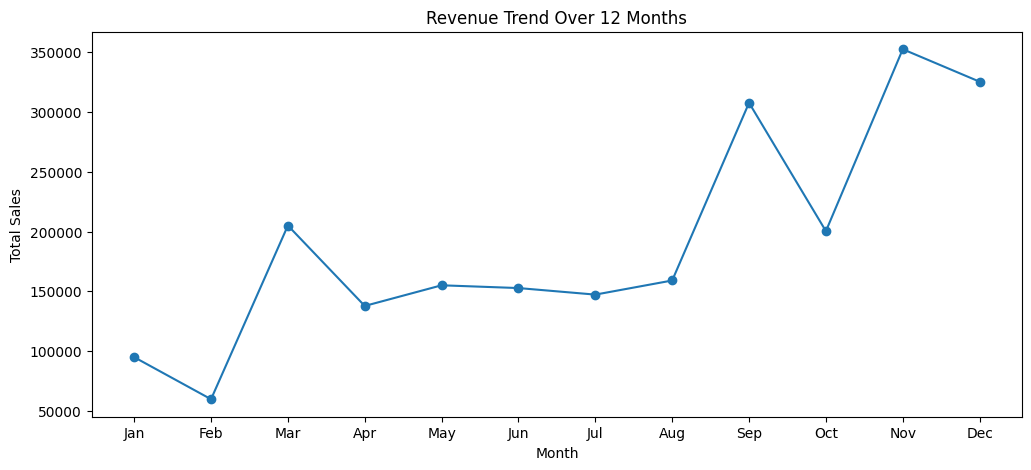

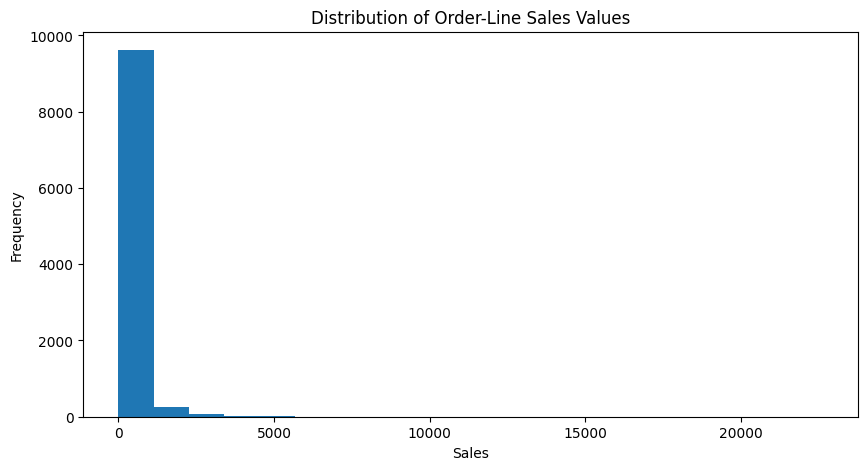

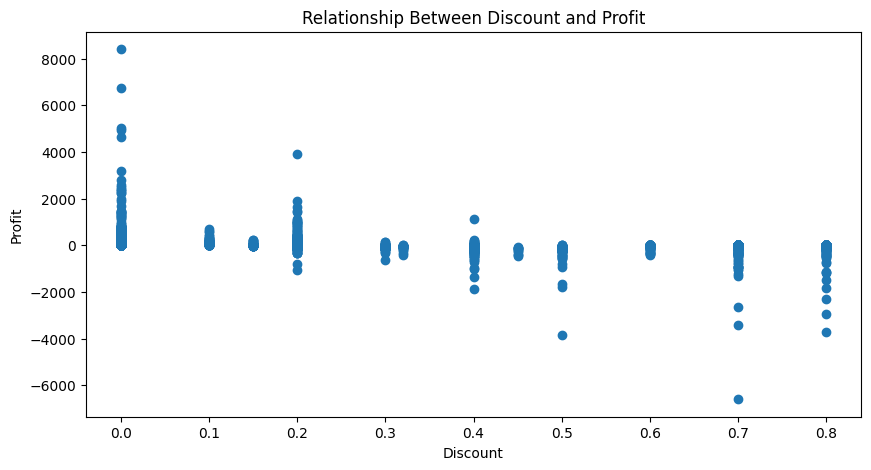

In [41]:
# Task 2(a): Compare total sales across the top 5 sub-categories

top5_subcategories = df.groupby('Sub-Category')['Sales'].sum().nlargest(5)

plt.figure(figsize=(10, 5))
plt.bar(top5_subcategories.index, top5_subcategories.values)
plt.xlabel('Sub-Category')
plt.ylabel('Total Sales')
plt.title('Top 5 Sub-Categories by Total Sales')
plt.show()
print("Bar chart is the best option to compare the magnitude across catogeries")
print("The pie chart would be a weak option as it would exceed the 4 catogeries limit")

# Task 2(b): Show the revenue trend over time

plt.figure(figsize=(12, 5))
plt.plot(months, monthly_sales.values, marker='o')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.title('Revenue Trend Over 12 Months')
plt.show()


# Task 2(c): Show the distribution of order-line sales values

plt.figure(figsize=(10, 5))
plt.hist(df['Sales'], bins=20)
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.title('Distribution of Order-Line Sales Values')
plt.show()


# Task 2(d): Show the relationship between discount level and profit

plt.figure(figsize=(10, 5))
plt.scatter(df['Discount'], df['Profit'])
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.title('Relationship Between Discount and Profit')
plt.show()

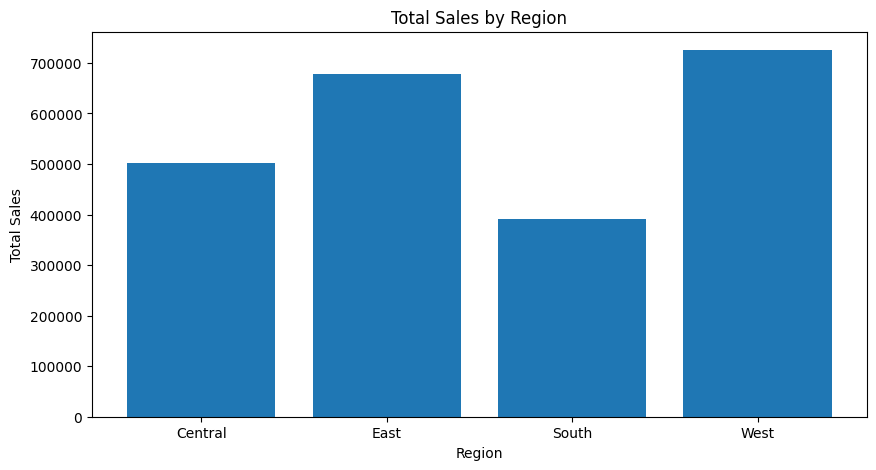

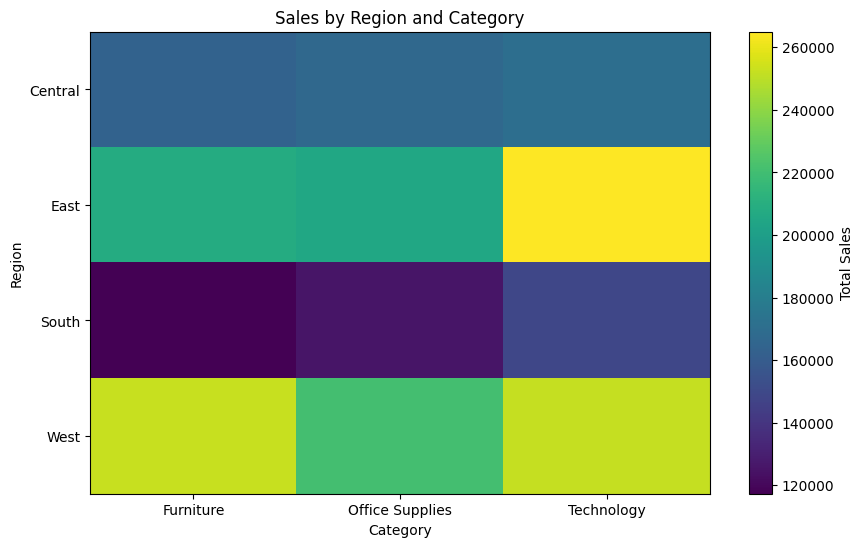

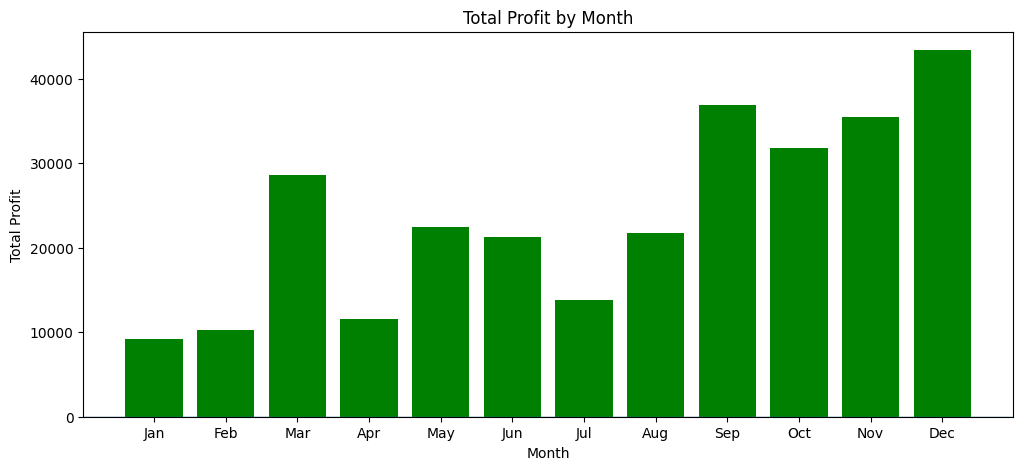

In [33]:
# Task 3(a): Total Sales by Region

region_sales = df.groupby('Region')['Sales'].sum()

plt.figure(figsize=(10, 5))
plt.bar(region_sales.index, region_sales.values)
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.title('Total Sales by Region')
plt.show()


# Task 3(b): Sales by Region and Category - Heatmap

region_category_sales = df.pivot_table(
    values='Sales',
    index='Region',
    columns='Category',
    aggfunc='sum'
)

plt.figure(figsize=(10, 6))
plt.imshow(region_category_sales, aspect='auto')
plt.xticks(range(len(region_category_sales.columns)), region_category_sales.columns)
plt.yticks(range(len(region_category_sales.index)), region_category_sales.index)
plt.xlabel('Category')
plt.ylabel('Region')
plt.title('Sales by Region and Category')
plt.colorbar(label='Total Sales')
plt.show()


# Task 3(c): Total Profit by Month - Diverging Color Chart

monthly_profit = df.groupby(
    df['Order Date'].dt.month
)['Profit'].sum()

monthly_profit = monthly_profit.reindex(range(1, 13), fill_value=0)

plt.figure(figsize=(12, 5))
plt.bar(months, monthly_profit.values, color=[
    'red' if value < 0 else 'green'
    for value in monthly_profit.values
])
plt.axhline(0, linewidth=1)
plt.xlabel('Month')
plt.ylabel('Total Profit')
plt.title('Total Profit by Month')
plt.show()

Red Contrast Ratio: 4.0
FAIL: Below WCAG AA 4.5:1
Green Contrast Ratio: 5.14
PASS: WCAG AA


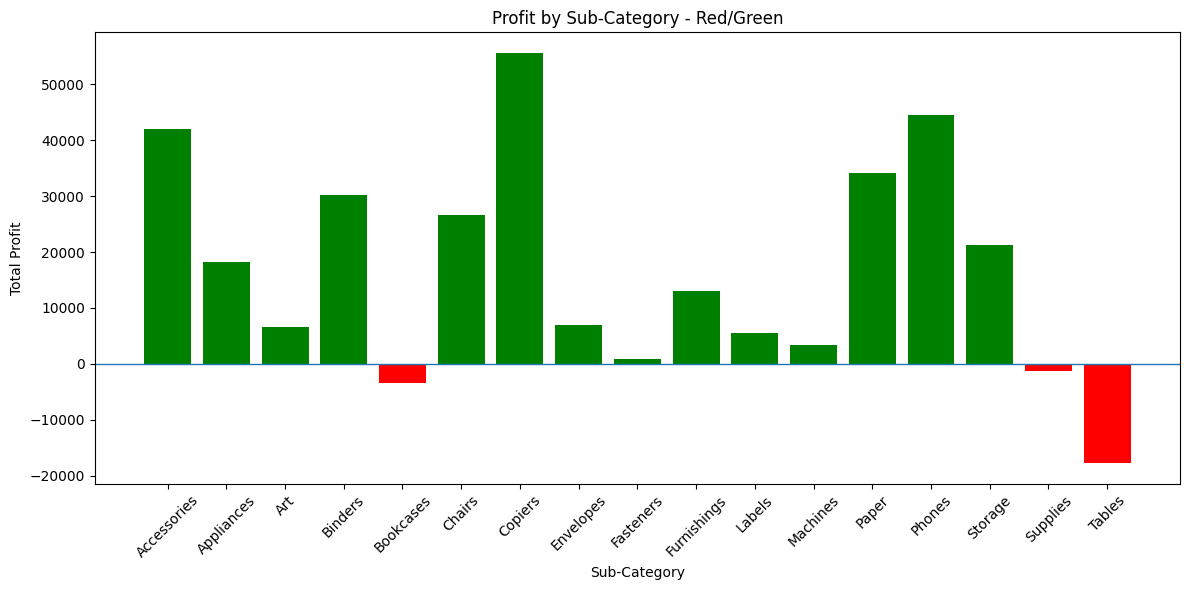

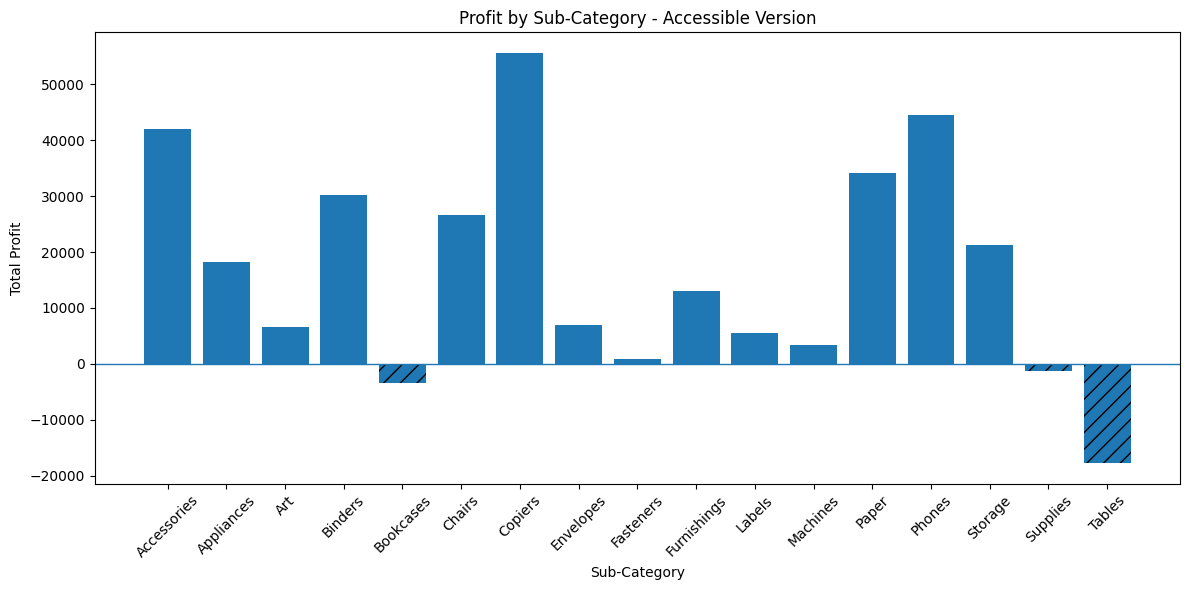

In [34]:
# Task 4(a): WCAG Contrast Ratio

def contrast_ratio(rgb1, rgb2):
    rgb1 = np.array(rgb1) / 255
    rgb2 = np.array(rgb2) / 255

    def luminance(rgb):
        rgb = np.where(
            rgb <= 0.03928,
            rgb / 12.92,
            ((rgb + 0.055) / 1.055) ** 2.4
        )
        return 0.2126 * rgb[0] + 0.7152 * rgb[1] + 0.0722 * rgb[2]

    L1 = luminance(rgb1)
    L2 = luminance(rgb2)

    return (max(L1, L2) + 0.05) / (min(L1, L2) + 0.05)


colors = {
    'Red': (255, 0, 0),
    'Green': (0, 128, 0)
}

background = (255, 255, 255)

for name, rgb in colors.items():
    ratio = contrast_ratio(rgb, background)
    print(name, 'Contrast Ratio:', round(ratio, 2))
    if ratio < 4.5:
        print('FAIL: Below WCAG AA 4.5:1')
    else:
        print('PASS: WCAG AA')


# Task 4(b): Profit by Sub-Category using Red and Green

subcategory_profit = df.groupby('Sub-Category')['Profit'].sum()

plt.figure(figsize=(12, 6))
plt.bar(
    subcategory_profit.index,
    subcategory_profit.values,
    color=[
        'red' if value < 0 else 'green'
        for value in subcategory_profit.values
    ]
)
plt.axhline(0, linewidth=1)
plt.xticks(rotation=45)
plt.xlabel('Sub-Category')
plt.ylabel('Total Profit')
plt.title('Profit by Sub-Category - Red/Green')
plt.tight_layout()
plt.show()


# Fixed Version: Hatching

plt.figure(figsize=(12, 6))

bars = plt.bar(
    subcategory_profit.index,
    subcategory_profit.values
)

for bar, value in zip(bars, subcategory_profit.values):
    if value < 0:
        bar.set_hatch('//')

plt.axhline(0, linewidth=1)
plt.xticks(rotation=45)
plt.xlabel('Sub-Category')
plt.ylabel('Total Profit')
plt.title('Profit by Sub-Category - Accessible Version')
plt.tight_layout()
plt.show()

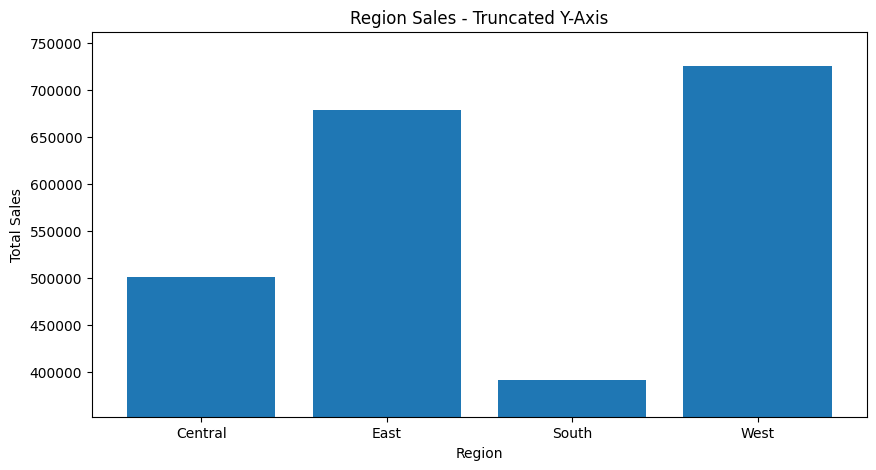

Caption: Truncated y-axis exaggerates the visual differences between regions by not starting at zero.


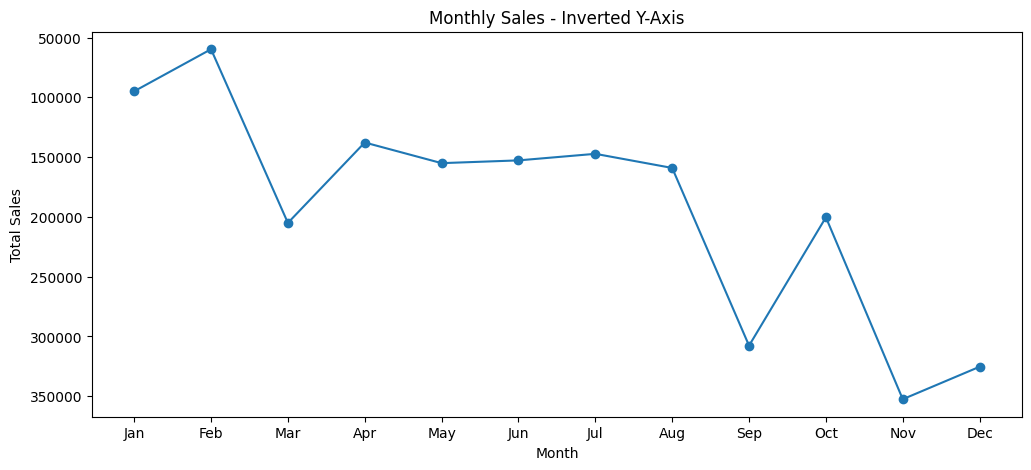

Caption: Inverted y-axis reverses the visual direction of the values and can make increases appear as decreases.


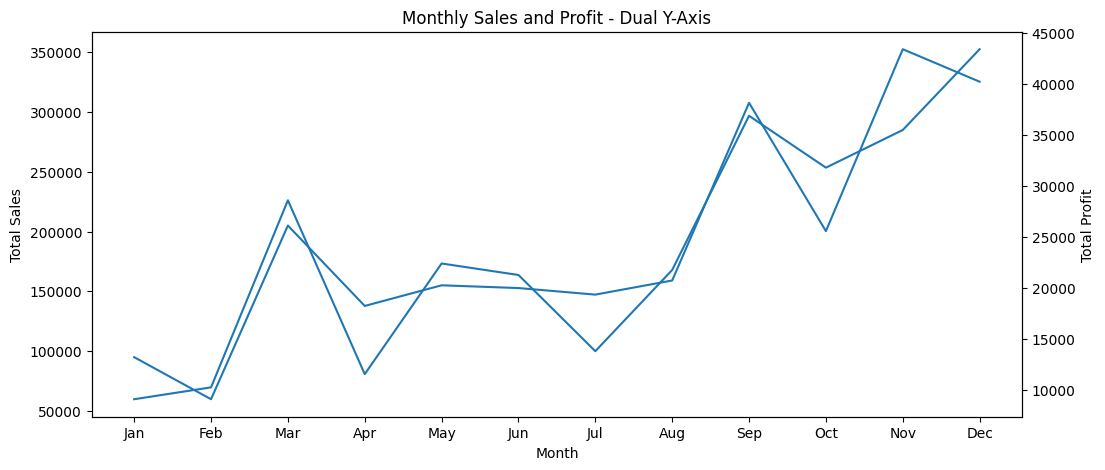

Caption: Dual y-axes use separate scales for sales and profit, which can falsely imply a stronger correlation between unrelated measures.


In [35]:
#Task 5
# Task 5(a): Truncated Y-Axis on Region Sales Chart

region_sales = df.groupby('Region')['Sales'].sum()

plt.figure(figsize=(10, 5))
plt.bar(region_sales.index, region_sales.values)
plt.ylim(region_sales.min() * 0.9, region_sales.max() * 1.05)
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.title('Region Sales - Truncated Y-Axis')
plt.show()

print('Caption: Truncated y-axis exaggerates the visual differences between regions by not starting at zero.')


# Task 5(b): Inverted Y-Axis on Monthly Sales

monthly_sales = df.groupby(
    df['Order Date'].dt.month
)['Sales'].sum()

monthly_sales = monthly_sales.reindex(range(1, 13), fill_value=0)

plt.figure(figsize=(12, 5))
plt.plot(months, monthly_sales.values, marker='o')
plt.gca().invert_yaxis()
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.title('Monthly Sales - Inverted Y-Axis')
plt.show()

print('Caption: Inverted y-axis reverses the visual direction of the values and can make increases appear as decreases.')


# Task 5(c): Dual Y-Axes with Unrelated Measures

monthly_profit = df.groupby(
    df['Order Date'].dt.month
)['Profit'].sum()

monthly_profit = monthly_profit.reindex(range(1, 13), fill_value=0)

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(months, monthly_sales.values)
ax1.set_xlabel('Month')
ax1.set_ylabel('Total Sales')

ax2 = ax1.twinx()
ax2.plot(months, monthly_profit.values)
ax2.set_ylabel('Total Profit')

plt.title('Monthly Sales and Profit - Dual Y-Axis')
plt.show()

print('Caption: Dual y-axes use separate scales for sales and profit, which can falsely imply a stronger correlation between unrelated measures.')

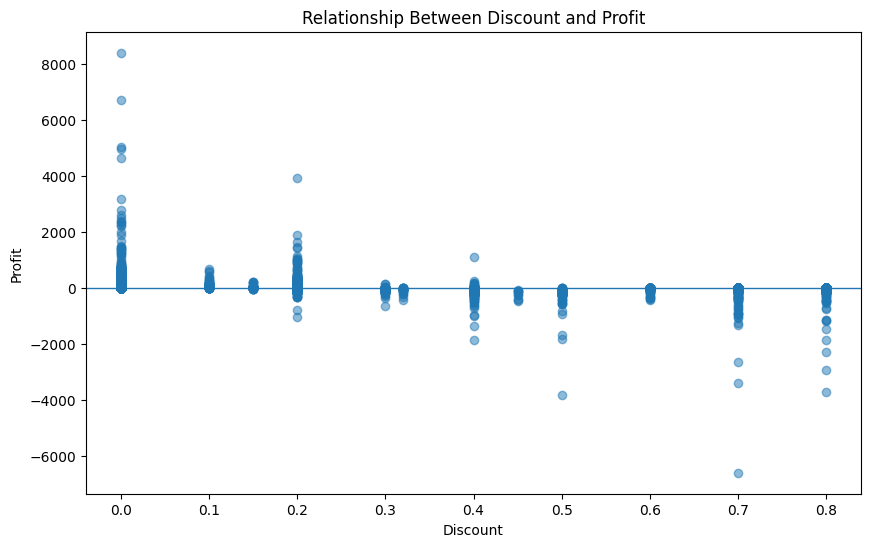

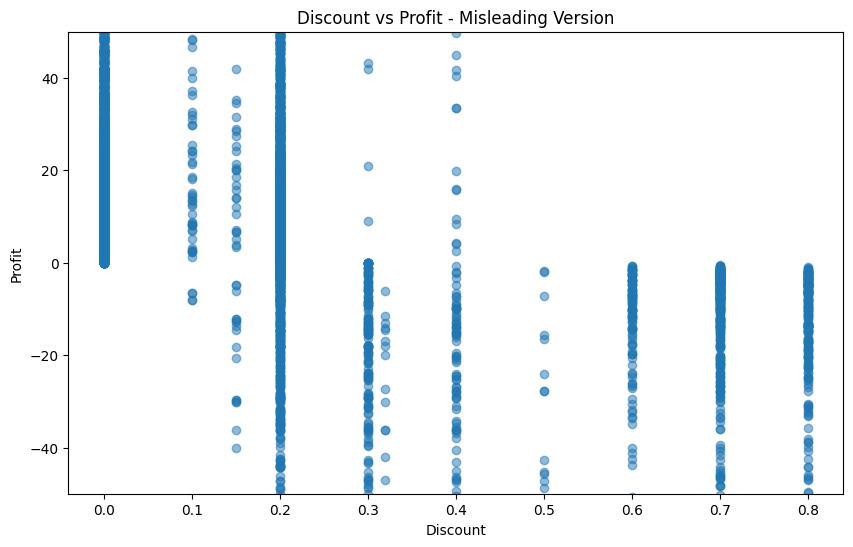

In [36]:
# Task 6: Is discounting hurting profit?

# Honest visualization

plt.figure(figsize=(10, 6))
plt.scatter(df['Discount'], df['Profit'], alpha=0.5)
plt.axhline(0, linewidth=1)
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.title('Relationship Between Discount and Profit')
plt.show()


# Deliberately misleading visualization

plt.figure(figsize=(10, 6))
plt.scatter(df['Discount'], df['Profit'], alpha=0.5)
plt.ylim(-50, 50)
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.title('Discount vs Profit - Misleading Version')
plt.show()